In [5]:
import scanpy as sc 
adata=sc.read_h5ad('../data/processed/nsclc_qc.h5ad')

In [6]:
import matplotlib.pyplot as plt 
sc.settings.figdir ="../results/figures"

In [7]:
#normalize 
sc.pp.normalize_total(adata,target_sum=1e4)
sc.pp.log1p(adata)

In [8]:
#store normalized data
adata.raw = adata

In [9]:
# HVG
sc.pp.highly_variable_genes(adata,n_top_genes=2000)

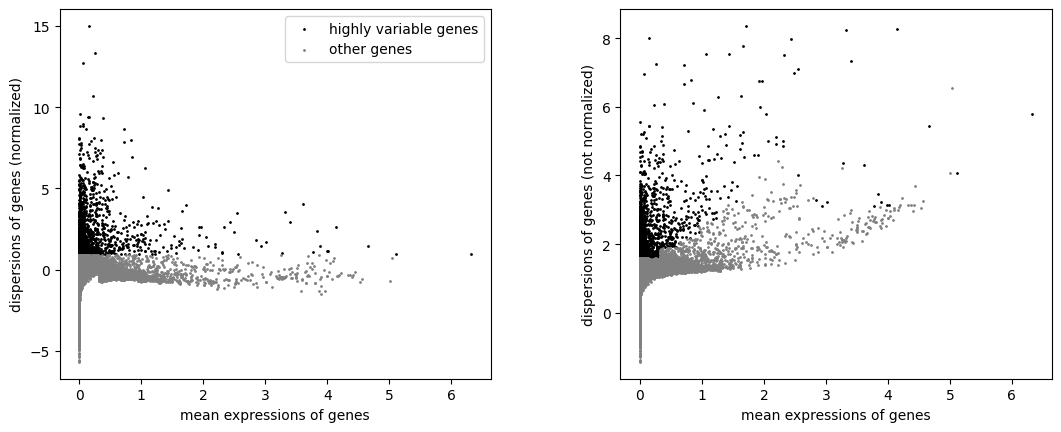

In [10]:
# visualize hvg's 
sc.pl.highly_variable_genes(adata,save='_hvg.png')

In [11]:
#keep only hvg's 
adata= adata[:,adata.var.highly_variable].copy()

In [12]:
#scale 
sc.pp.scale(adata,max_value = 10)

/opt/miniconda3/envs/singlecell/lib/python3.10/functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


In [13]:
#document and save 
adata.uns['qc_complete'] = True 

In [14]:
adata.write('../data/processed/preprocessed.h5ad')

In [19]:
adata.raw.X.max()

np.float32(9.095802)

In [20]:
adata.X.max()

np.float64(10.0)